In [34]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt
import statsmodels.api as sm
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy.stats import ttest_ind
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, RepeatedStratifiedKFold, cross_val_score
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, classification_report, balanced_accuracy_score, confusion_matrix, precision_recall_curve, roc_auc_score, make_scorer, accuracy_score, f1_score, r2_score, mean_absolute_error, mutual_info_score, roc_curve, zero_one_loss, silhouette_score
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, normalize
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier


Text(0.5, 1.0, 'Weekly samples & defect ratio')

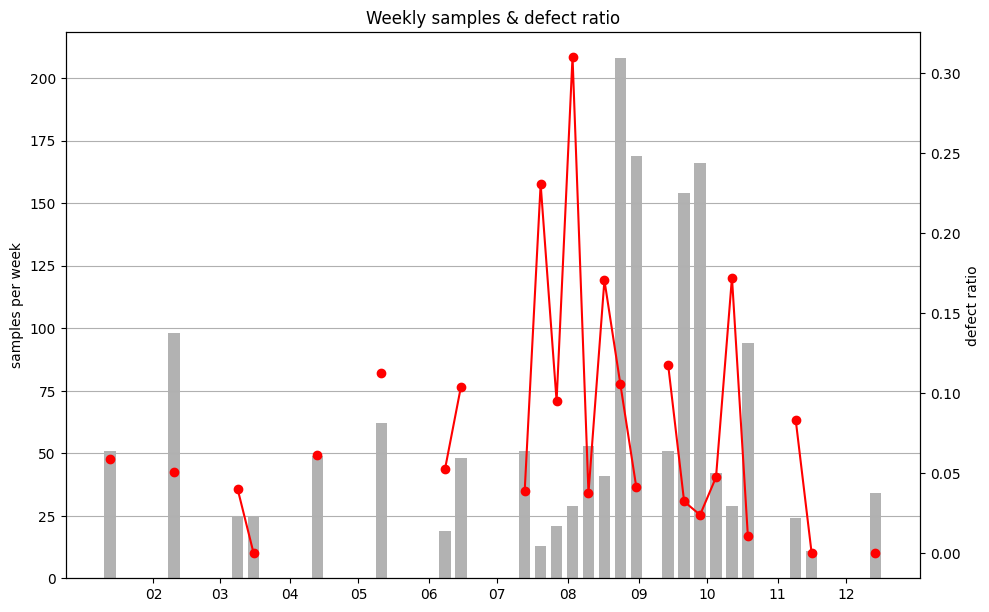

In [35]:
secom = pd.read_csv(data_path, sep='\t')
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

time_dt = pd.to_datetime(secom['Time'])
df = pd.DataFrame({'Time':time_dt, 'y':y}).sort_values('Time').set_index('Time')

w = df['y'].resample('W') # W means the end of the date
cnt, rate = w.size(), w.mean() # rate means 1/0 (fail/pass) less is better

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(cnt.index, cnt.values, width=5, alpha=0.3, color='k')
ax1.set_ylabel('samples per week')
ax1.grid(True, axis='y')

ax2 = ax1.twinx()
ax2.plot(rate.index, rate.values, marker='o', color='r')
ax2.set_ylabel('defect ratio')
months = pd.date_range(rate.index.min().normalize(),
                       rate.index.max().normalize(), freq='MS') 
ax2.set_xticks(months)
ax2.set_xticklabels([d.strftime('%m') for d in months], rotation=0, ha='center')

plt.tight_layout()
plt.title('Weekly samples & defect ratio')


#### PCA + Kmeans, 2 clusters

PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


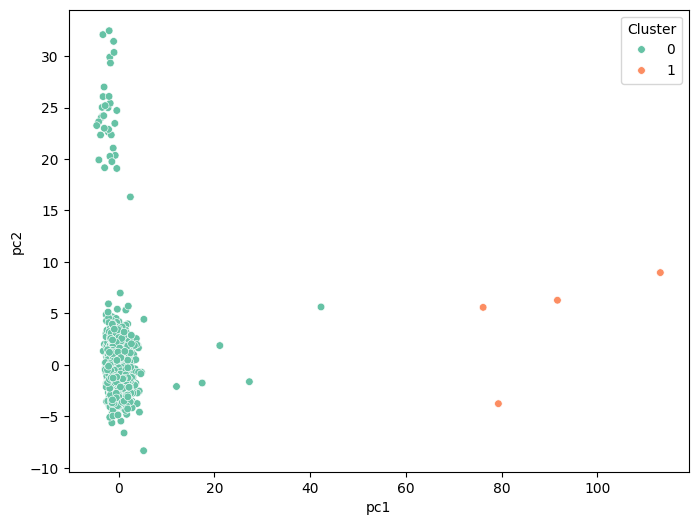

In [36]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

#### StandardScaler + Kmeans + elbow, 4 cluster

Elbow 法推測的最佳 K = 4


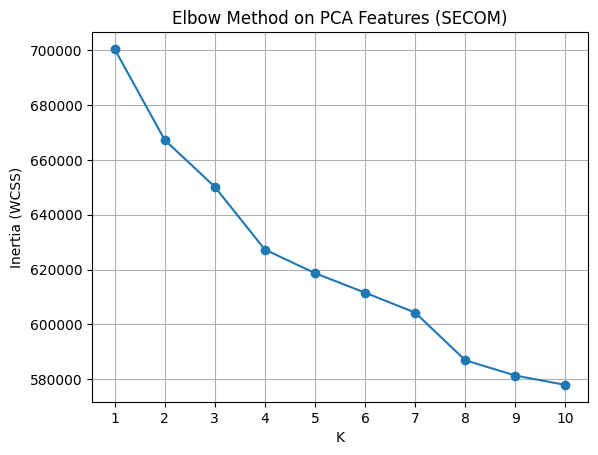

cluster sizes: {0: 32, 1: 722, 2: 4, 3: 809}
cluster   0    1  2    3
y                       
0        25  667  3  768
1         7   55  1   41
PCA 保留 131 個主成分


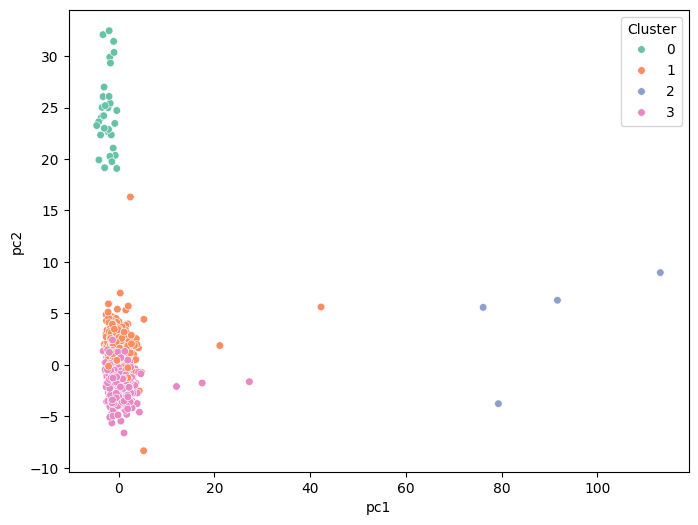

In [27]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

Ks = list(range(1, 11))  # 可自行調整上限，例如到 15 或 20
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_std)
    inertias.append(km.inertia_)  # WCSS

# 找 elbow（幾何法：點到首尾連線的最大距離）
def find_elbow(Ks, inertias):
    x = np.array(Ks, dtype=float)
    y = np.array(inertias, dtype=float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    # 各點到線段 p1-p2 的距離
    pts = np.column_stack([x, y])
    distances = np.abs(np.cross(p2 - p1, pts - p1)) / np.linalg.norm(p2 - p1)
    return int(x[np.argmax(distances)])

elbow_k = find_elbow(Ks, inertias)
print(f"Elbow 法推測的最佳 K = {elbow_k}")

# 繪圖
plt.figure()
plt.plot(Ks, inertias, marker='o')
plt.xticks(Ks)
plt.xlabel('K')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method on PCA Features (SECOM)')
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=elbow_k, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_std)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])
X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

#### PCA + Kmeans + elbow, 6 cluster

PCA 保留 131 個主成分
Elbow 法推測的最佳 K = 6


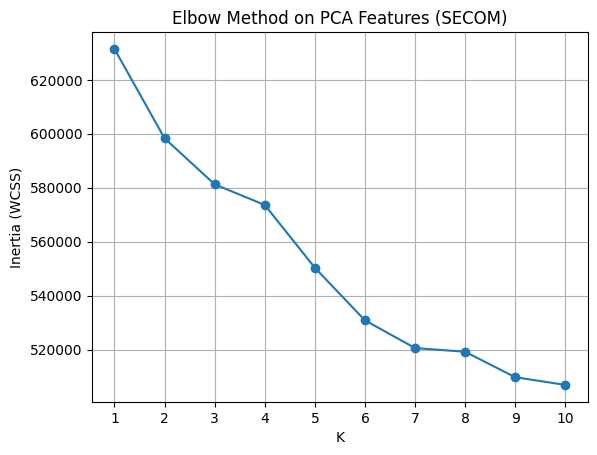

cluster sizes: {0: 32, 1: 599, 2: 679, 3: 4, 4: 1, 5: 252}
cluster   0    1    2  3  4    5
y                               
0        25  563  627  3  1  244
1         7   36   52  1  0    8


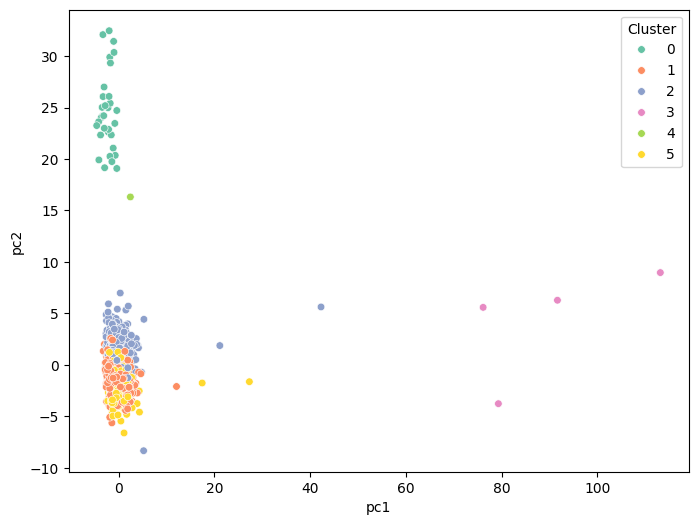

In [28]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

Ks = list(range(1, 11))  # 可自行調整上限，例如到 15 或 20
inertias = []

for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    km.fit(X_pca_df)
    inertias.append(km.inertia_)  # WCSS

# 找 elbow（幾何法：點到首尾連線的最大距離）
def find_elbow(Ks, inertias):
    x = np.array(Ks, dtype=float)
    y = np.array(inertias, dtype=float)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    # 各點到線段 p1-p2 的距離
    pts = np.column_stack([x, y])
    distances = np.abs(np.cross(p2 - p1, pts - p1)) / np.linalg.norm(p2 - p1)
    return int(x[np.argmax(distances)])

elbow_k = find_elbow(Ks, inertias)
print(f"Elbow 法推測的最佳 K = {elbow_k}")

# 繪圖
plt.figure()
plt.plot(Ks, inertias, marker='o')
plt.xticks(Ks)
plt.xlabel('K')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method on PCA Features (SECOM)')
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=elbow_k, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

#### 有pca, 沒有oversampling

In [31]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[263  29]
 [ 14   7]]

SVM(RBF) confusion matrix:
[[292   0]
 [ 21   0]]

DecisionTree confusion matrix:
[[279  13]
 [ 18   3]]

RandomForest confusion matrix:
[[292   0]
 [ 21   0]]

XGBoost confusion matrix:
[[292   0]
 [ 21   0]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8626  0.0993       0.3333       0.9007  0.5479
SVM(RBF)            0.9329  0.0000       0.0000       1.0000  0.0000
DecisionTree        0.9010  0.0445       0.1429       0.9555  0.3695
RandomForest        0.9329  0.0000       0.0000       1.0000  0.0000
XGBoost             0.9329  0.0000       0.0000       1.0000  0.0000


#### 用X_pca做重複事情

In [ ]:
mask = (labels == 0)
X_sub = X_pca_df.drop(columns=['Cluster']).loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))

#### 有pca, oversampling

In [32]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[265  27]
 [ 15   6]]

SVM(RBF) confusion matrix:
[[292   0]
 [ 21   0]]

DecisionTree confusion matrix:
[[259  33]
 [ 13   8]]

RandomForest confusion matrix:
[[292   0]
 [ 20   1]]

XGBoost confusion matrix:
[[290   2]
 [ 19   2]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8658  0.0925       0.2857       0.9075  0.5092
SVM(RBF)            0.9329  0.0000       0.0000       1.0000  0.0000
DecisionTree        0.8530  0.1130       0.3810       0.8870  0.5813
RandomForest        0.9361  0.0000       0.0476       1.0000  0.2182
XGBoost             0.9329  0.0068       0.0952       0.9932  0.3075


In [33]:
# DecisionTree 混淆矩陣
dtree = models["DecisionTree"]
yhat_dt = predict_labels(dtree, Xte)

cm = confusion_matrix(yte, yhat_dt, labels=[0,1])
TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f"\nDecisionTree confusion matrix:\n{cm}")

# 建立 mask
mask_tn = (yte==0) & (yhat_dt==0)
mask_fp = (yte==0) & (yhat_dt==1)

# 各類樣本數
print(f"TN={mask_tn.sum()}, FP={mask_fp.sum()}")

Xte_df = pd.DataFrame(Xte, columns=X.columns)
# 計算每個特徵的平均差異與 p-value
diffs = []
for col in Xte_df.columns:
    group_tn = Xte_df.loc[mask_tn, col]
    group_fp = Xte_df.loc[mask_fp, col]
    stat, p = ttest_ind(group_fp, group_tn, equal_var=False, nan_policy='omit')
    mean_diff = group_fp.mean() - group_tn.mean()
    diffs.append((col, mean_diff, p))

# 排序後輸出前 20 名
df_diff = pd.DataFrame(diffs, columns=['feature', 'mean_diff', 'p_value'])
df_diff['abs_diff'] = df_diff['mean_diff'].abs()
df_diff = df_diff.sort_values('p_value', ascending=True).head(20)
print("\np-value小到大排序")
print(df_diff.round(4))


DecisionTree confusion matrix:
[[259  33]
 [ 13   8]]
TN=259, FP=33

p-value小到大排序
    feature  mean_diff  p_value  abs_diff
54      x60     0.6589   0.0001    0.6589
249    x310     0.6029   0.0004    0.6029
247    x308     0.6029   0.0004    0.6029
342    x444     0.6173   0.0006    0.6173
158    x175     0.6253   0.0006    0.6253
156    x173     0.6253   0.0006    0.6253
344    x446     0.6321   0.0006    0.6321
433    x577    -0.2001   0.0009    0.2001
431    x575    -0.2012   0.0010    0.2012
429    x573    -0.2019   0.0010    0.2019
26      x29    -0.5807   0.0018    0.5807
428    x572     0.4276   0.0036    0.4276
100    x113     0.2473   0.0114    0.2473
94     x104     0.4255   0.0121    0.4255
21      x24     0.3723   0.0153    0.3723
69      x77    -0.3858   0.0178    0.3858
33      x36    -0.1703   0.0245    0.1703
268    x339    -0.0716   0.0275    0.0716
67      x74    -0.1474   0.0361    0.1474
177    x203    -0.1001   0.0387    0.1001


c:\Users\USER\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:523: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


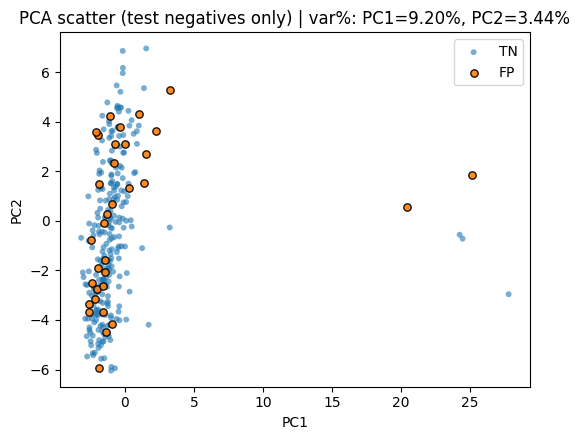

In [64]:
Xtr_df = pd.DataFrame(Xtr, columns=X.columns)
# 1) 在訓練集 fit PCA（避免資料外洩），再轉換測試集
pca = PCA(n_components=2, random_state=42)
pca.fit(Xtr_df)                 # fit on train
Z_te = pca.transform(Xte_df)    # transform test

# 2) 繪圖：TN(藍)、FP(紅)，並標出各自質心
plt.figure(figsize=(5.5,4.5))
plt.scatter(Z_te[mask_tn,0], Z_te[mask_tn,1], s=18, alpha=0.6, label='TN', edgecolor='none')
plt.scatter(Z_te[mask_fp,0], Z_te[mask_fp,1], s=28, alpha=0.9, label='FP', edgecolor='k')

plt.title(f'PCA scatter (test negatives only) | var%: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend()
plt.tight_layout(); plt.show()

# 3) 哪些特徵驅動分離？看 PC loading 與 FP/TN 投影差
loadings = pd.DataFrame(pca.components_.T, index=Xtr_df.columns, columns=['PC1','PC2'])
# 方向：FP 與 TN 在 PC1/2 的均值差
d_pc = pd.Series(Z_te[mask_fp].mean(axis=0) - Z_te[mask_tn].mean(axis=0), index=['PC1','PC2'])
# 按與分離方向內積大小排序
score = loadings.dot(d_pc.values)
top_feats = score.abs().sort_values(ascending=False).head(15)
# print("\nPCA 顯示最驅動 FP↔TN 分離的特徵（依投影分數）：")
# print(pd.DataFrame({'score':score[top_feats.index].round(4)}))

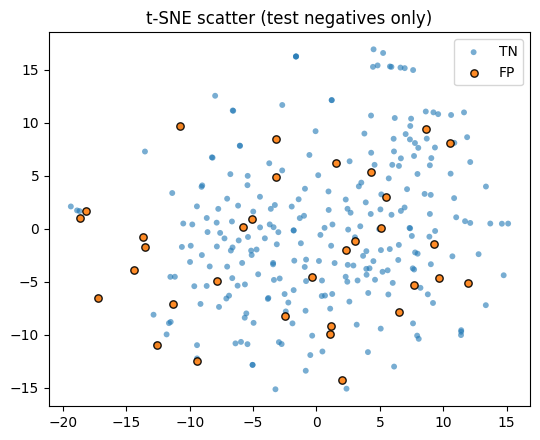

In [57]:
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42, n_iter=1500)
# t-SNE 建議只在測試集執行並用全部特徵直接嵌入
Z_tsne = tsne.fit_transform(Xte_df)

plt.figure(figsize=(5.5,4.5))
plt.scatter(Z_tsne[mask_tn,0], Z_tsne[mask_tn,1], s=18, alpha=0.6, label='TN', edgecolor='none')
plt.scatter(Z_tsne[mask_fp,0], Z_tsne[mask_fp,1], s=28, alpha=0.9, label='FP', edgecolor='k')
plt.title('t-SNE scatter (test negatives only)')
plt.legend(); plt.tight_layout(); plt.show()

#### 用X_pca做重複事情

In [ ]:
mask = (labels == 0)
X_sub = X_pca_df.drop(columns=['Cluster']).loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))

#### 原始資料, 沒有pca, 有oversampling

In [29]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

Xtr, Xte, ytr, yte = train_test_split(X_std, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

results, cms = [], {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    yhat = predict_labels(clf, Xte)
    met = compute_metrics(yte, yhat)
    print(f"\n{name} confusion matrix:\n{met['cm']}")
    cms[name] = met.pop('cm')
    met['model'] = name
    results.append(met)

metrics_df = pd.DataFrame(results).set_index('model').loc[models.keys()]
print("\nSummary metrics:\n", metrics_df.round(4))


LogisticRegression confusion matrix:
[[262  31]
 [ 17   4]]

SVM(RBF) confusion matrix:
[[293   0]
 [ 21   0]]

DecisionTree confusion matrix:
[[247  46]
 [ 18   3]]

RandomForest confusion matrix:
[[293   0]
 [ 21   0]]

XGBoost confusion matrix:
[[292   1]
 [ 21   0]]

Summary metrics:
                        acc     FAR  sensitivity  specificity      GM
model                                                               
LogisticRegression  0.8471  0.1058       0.1905       0.8942  0.4127
SVM(RBF)            0.9331  0.0000       0.0000       1.0000  0.0000
DecisionTree        0.7962  0.1570       0.1429       0.8430  0.3470
RandomForest        0.9331  0.0000       0.0000       1.0000  0.0000
XGBoost             0.9299  0.0034       0.0000       0.9966  0.0000


#### 有pca, oversampling, 5-folds cv

In [31]:
mask = (labels == 0)
X_sub = X_std.loc[mask].values
y_sub = y.loc[mask].values

Xtr, Xte, ytr, yte = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub)

smote = SMOTE(random_state=42)
Xtr, ytr = smote.fit_resample(Xtr, ytr)

def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    acc = accuracy_score(y_true, y_pred)
    sensitivity = TP/(TP+FN) if (TP+FN)>0 else np.nan
    specificity = TN/(TN+FP) if (TN+FP)>0 else np.nan
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    GM = np.sqrt(sensitivity*specificity) if (not np.isnan(sensitivity) and not np.isnan(specificity)) else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'sensitivity':sensitivity, 'specificity':specificity, 'GM':GM}

# 類別不平衡參數
pos = (ytr==1).sum()
neg = (ytr==0).sum()
spw = neg/pos if pos>0 else 1.0

models = {"LogisticRegression":LogisticRegression(max_iter=2000, class_weight='balanced', penalty='l1', solver='liblinear', random_state=42),
          "SVM(RBF)":SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
          "DecisionTree":DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, class_weight='balanced', random_state=42),
          "RandomForest":RandomForestClassifier(n_estimators=1000, max_depth=None, min_samples_leaf=2, class_weight='balanced_subsample', n_jobs=-1, random_state=42),
          "XGBoost":XGBClassifier(n_estimators=1000, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, objective='binary:logistic', eval_metric='logloss', tree_method='hist')
          }

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42)

cv_results = []
for name, clf in models.items():
    fold_metrics = []
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        clf.fit(Xtr_res, ytr_res)
        yhat = predict_labels(clf, Xte)
        met = compute_metrics(yte, yhat)
        fold_metrics.append(met)
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, GM={met['GM']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[models.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== LogisticRegression ===
Fold 1: acc=0.872, FAR=0.082,GM=0.467
Fold 2: acc=0.850, FAR=0.116,GM=0.580
Fold 3: acc=0.863, FAR=0.103,GM=0.585
Fold 4: acc=0.843, FAR=0.113,GM=0.421
Fold 5: acc=0.859, FAR=0.103,GM=0.519

=== SVM(RBF) ===
Fold 1: acc=0.930, FAR=0.003,GM=0.000
Fold 2: acc=0.933, FAR=0.000,GM=0.000
Fold 3: acc=0.933, FAR=0.000,GM=0.000
Fold 4: acc=0.929, FAR=0.007,GM=0.000
Fold 5: acc=0.936, FAR=0.000,GM=0.000

=== DecisionTree ===
Fold 1: acc=0.856, FAR=0.092,GM=0.360
Fold 2: acc=0.824, FAR=0.140,GM=0.535
Fold 3: acc=0.815, FAR=0.154,GM=0.568
Fold 4: acc=0.804, FAR=0.154,GM=0.411
Fold 5: acc=0.849, FAR=0.106,GM=0.423

=== RandomForest ===
Fold 1: acc=0.927, FAR=0.007,GM=0.000
Fold 2: acc=0.930, FAR=0.003,GM=0.000
Fold 3: acc=0.933, FAR=0.000,GM=0.000
Fold 4: acc=0.936, FAR=0.000,GM=0.000
Fold 5: acc=0.936, FAR=0.000,GM=0.000

=== XGBoost ===
Fold 1: acc=0.923, FAR=0.014,GM=0.217
Fold 2: acc=0.920, FAR=0.017,GM=0.216
Fold 3: acc=0.927, FAR=0.010,GM=0.217
Fold 4: acc=0.926, 

---
---

In [ ]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

X_cos = pd.DataFrame(normalize(X_std, norm='l2'), columns=X.columns, index=X.index)

kmeans = KMeans(n_clusters=2, n_init=100, random_state=42)
labels = kmeans.fit_predict(X_cos)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

---
---

In [ ]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

# 先用 k 距離找 eps（常見做法：取第 k 個近鄰距離的高分位數）
k = 10
nbrs = NearestNeighbors(n_neighbors=k).fit(X_std)
dists, _ = nbrs.kneighbors(X_std)
k_dists = np.sort(dists[:, -1])             # 每點到第k鄰的距離
eps = np.percentile(k_dists, 90)            # 你也可改 85~95 做靈敏度分析

db = DBSCAN(eps=eps, min_samples=k, n_jobs=-1)
labels = db.fit_predict(X_std)              # -1 代表噪聲點

sizes = pd.Series(labels, name='cluster').value_counts().sort_index()
print('cluster sizes (含 -1=noise):', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'cluster': labels})
ct = pd.crosstab(df['y'], df['cluster'], rownames=['y'], colnames=['cluster'])
print(ct)